<a href="https://colab.research.google.com/github/optofficial2026/2026-OPT-1st-Homework/blob/jieun/Week2/Jieun_NN_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Neural Network on CIFAR-10 with Regularization

In this assignment, you will:
1. Build a baseline CNN for CIFAR-10 classification
2. Implement and compare regularization techniques (Dropout, BatchNorm)
3. Combine all techniques to build your best model
4. Visualize how CNNs learn (filters, feature maps, Grad-CAM)
5. Analyze and compare results

**Rules:**
- You may use PyTorch (or TensorFlow if you prefer)
- Do NOT use pretrained models
- Fill in all `# TODO` sections
- Report final test accuracy for each experiment

---

## Grading Rubric

Your grade is determined by your **Best Model** (Task 4) **final test accuracy**, evaluated in Task 6:

| Grade | Test Accuracy | Description |
|-------|--------------|-------------|
| **A+** | >= 85% | Excellent — strong architecture with well-tuned regularization |
| **A** | >= 82% | Great — good combination of techniques |
| **B+** | >= 79% | Good effort — room for optimization |
| **B** | >= 76% | Decent — used some techniques effectively |
| **C** | >= 70% | Minimal effort — near baseline performance |
| **F** | < 70% | Needs more work |

**Per-task minimum thresholds** (must pass all to receive full credit):
- Task 1 (Baseline): >= 65% — confirms a working CNN
- Task 2 (Dropout): >= 65%
- Task 3 (BatchNorm): >= 70%
- Task 4 (Best Model): >= 70%
- Task 5 (Visualization): Complete all visualizations and answer questions
- Task 6 (Analysis): Answer all questions thoughtfully

## 0. Setup

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 1. Data Loading

CIFAR-10: 60,000 32x32 color images in 10 classes (50k train, 10k test).

We split the training set into **train (45k)** and **validation (5k)** so that we tune hyperparameters on the validation set and only evaluate on the test set at the very end.

In [3]:
# Basic transform (no augmentation yet)
transform_basic = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Full training set (we will split into train + val)
full_trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_basic)

# Split: 45k train, 5k validation
trainset, valset = torch.utils.data.random_split(full_trainset, [45000, 5000],
                                                  generator=torch.Generator().manual_seed(42))

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
valloader = torch.utils.data.DataLoader(valset, batch_size=128, shuffle=False, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_basic)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:02<00:00, 78.1MB/s]


## 2. Training & Evaluation Helpers

> **Note:** Dropout and BatchNorm behave differently during training vs. evaluation. The `train()` function calls `model.train()` and `evaluate()` calls `model.eval()` — this is critical for correct results.

In [16]:
def train(model, loader, criterion, optimizer, epochs=20):
    """Train the model. Returns lists of (train_loss, train_acc) per epoch."""
    model.train()
    history = {'loss': [], 'acc': []}
    for epoch in range(epochs):
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
        epoch_loss = running_loss / total
        epoch_acc = correct / total
        history['loss'].append(epoch_loss)
        history['acc'].append(epoch_acc)
        print(f'Epoch {epoch+1:2d}/{epochs} \u2014 Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}')

        if scheduler is not None:
            scheduler.step()

    return history


def evaluate(model, loader):
    """Evaluate the model on a dataset. Returns (loss, accuracy)."""
    model.eval()
    criterion = nn.CrossEntropyLoss()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

---
## Task 1: Baseline CNN (No Regularization)

Build a simple CNN. Suggested architecture:
- 2~3 Conv blocks (Conv2d -> ReLU -> MaxPool2d)
- 1~2 Fully connected layers
- No dropout, no batch norm, no weight decay

In [5]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Conv Block 1: 32x32 -> 16x16
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Block 2: 16x16 -> 8x8
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Block 3: 8x8 -> 4x4
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )


    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x



baseline = BaselineCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

hist_baseline = train(baseline, trainloader, criterion, optimizer, epochs=20)
val_loss, val_acc = evaluate(baseline, valloader)
print(f'\n[Baseline] Val Accuracy: {val_acc:.4f}')

Epoch  1/20 — Loss: 1.5762, Acc: 0.4242
Epoch  2/20 — Loss: 1.2162, Acc: 0.5667
Epoch  3/20 — Loss: 1.0535, Acc: 0.6258
Epoch  4/20 — Loss: 0.9340, Acc: 0.6715
Epoch  5/20 — Loss: 0.8506, Acc: 0.7000
Epoch  6/20 — Loss: 0.7788, Acc: 0.7250
Epoch  7/20 — Loss: 0.7133, Acc: 0.7482
Epoch  8/20 — Loss: 0.6614, Acc: 0.7683
Epoch  9/20 — Loss: 0.6099, Acc: 0.7863
Epoch 10/20 — Loss: 0.5643, Acc: 0.8018
Epoch 11/20 — Loss: 0.5226, Acc: 0.8168
Epoch 12/20 — Loss: 0.4858, Acc: 0.8303
Epoch 13/20 — Loss: 0.4432, Acc: 0.8440
Epoch 14/20 — Loss: 0.4088, Acc: 0.8580
Epoch 15/20 — Loss: 0.3728, Acc: 0.8692
Epoch 16/20 — Loss: 0.3358, Acc: 0.8838
Epoch 17/20 — Loss: 0.3094, Acc: 0.8912
Epoch 18/20 — Loss: 0.2825, Acc: 0.8989
Epoch 19/20 — Loss: 0.2523, Acc: 0.9107
Epoch 20/20 — Loss: 0.2328, Acc: 0.9181

[Baseline] Val Accuracy: 0.7214


---
## Task 2: Dropout Regularization

Copy your baseline and add **Dropout** layers. Experiment with dropout rates (e.g., 0.25, 0.5).

> **Tip:** Start with a lower rate like 0.25. High dropout (0.5) on small networks with few epochs can hurt training convergence — this is itself a useful observation.

In [6]:
class DropoutCNN(nn.Module):
    def __init__(self, drop_rate=0.25):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )


        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=drop_rate),
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(p=drop_rate),
            nn.Linear(128, 10)
        )


    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


dropout_model = DropoutCNN(drop_rate=0.25).to(device)
optimizer = optim.Adam(dropout_model.parameters(), lr=1e-3)

hist_dropout = train(dropout_model, trainloader, criterion, optimizer, epochs=20)
val_loss, val_acc = evaluate(dropout_model, valloader)
print(f'\n[Dropout] Val Accuracy: {val_acc:.4f}')

Epoch  1/20 — Loss: 1.6358, Acc: 0.4018
Epoch  2/20 — Loss: 1.3145, Acc: 0.5261
Epoch  3/20 — Loss: 1.1631, Acc: 0.5850
Epoch  4/20 — Loss: 1.0578, Acc: 0.6252
Epoch  5/20 — Loss: 0.9847, Acc: 0.6508
Epoch  6/20 — Loss: 0.9277, Acc: 0.6726
Epoch  7/20 — Loss: 0.8817, Acc: 0.6892
Epoch  8/20 — Loss: 0.8369, Acc: 0.7059
Epoch  9/20 — Loss: 0.7994, Acc: 0.7182
Epoch 10/20 — Loss: 0.7660, Acc: 0.7303
Epoch 11/20 — Loss: 0.7396, Acc: 0.7385
Epoch 12/20 — Loss: 0.7192, Acc: 0.7472
Epoch 13/20 — Loss: 0.6964, Acc: 0.7544
Epoch 14/20 — Loss: 0.6773, Acc: 0.7603
Epoch 15/20 — Loss: 0.6593, Acc: 0.7649
Epoch 16/20 — Loss: 0.6421, Acc: 0.7730
Epoch 17/20 — Loss: 0.6280, Acc: 0.7782
Epoch 18/20 — Loss: 0.6130, Acc: 0.7827
Epoch 19/20 — Loss: 0.5934, Acc: 0.7881
Epoch 20/20 — Loss: 0.5863, Acc: 0.7903

[Dropout] Val Accuracy: 0.7434


---
## Task 3: Batch Normalization

Copy your baseline and add **BatchNorm2d** (after conv layers) and/or **BatchNorm1d** (after FC layers).

In [7]:
class BatchNormCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # Conv Block 1
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Block 2
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Block 3
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )


        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128),
            nn.BatchNorm1d(num_features=128),
            nn.ReLU(),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


bn_model = BatchNormCNN().to(device)
optimizer = optim.Adam(bn_model.parameters(), lr=1e-3)

hist_bn = train(bn_model, trainloader, criterion, optimizer, epochs=20)
val_loss, val_acc = evaluate(bn_model, valloader)
print(f'\n[BatchNorm] Val Accuracy: {val_acc:.4f}')

Epoch  1/20 — Loss: 1.1884, Acc: 0.5808
Epoch  2/20 — Loss: 0.8448, Acc: 0.7043
Epoch  3/20 — Loss: 0.7004, Acc: 0.7549
Epoch  4/20 — Loss: 0.6001, Acc: 0.7924
Epoch  5/20 — Loss: 0.5169, Acc: 0.8184
Epoch  6/20 — Loss: 0.4480, Acc: 0.8457
Epoch  7/20 — Loss: 0.3911, Acc: 0.8666
Epoch  8/20 — Loss: 0.3324, Acc: 0.8846
Epoch  9/20 — Loss: 0.2894, Acc: 0.9035
Epoch 10/20 — Loss: 0.2462, Acc: 0.9190
Epoch 11/20 — Loss: 0.2057, Acc: 0.9324
Epoch 12/20 — Loss: 0.1763, Acc: 0.9434
Epoch 13/20 — Loss: 0.1558, Acc: 0.9501
Epoch 14/20 — Loss: 0.1334, Acc: 0.9578
Epoch 15/20 — Loss: 0.1107, Acc: 0.9669
Epoch 16/20 — Loss: 0.1025, Acc: 0.9684
Epoch 17/20 — Loss: 0.0948, Acc: 0.9707
Epoch 18/20 — Loss: 0.0946, Acc: 0.9713
Epoch 19/20 — Loss: 0.0848, Acc: 0.9730
Epoch 20/20 — Loss: 0.0700, Acc: 0.9787

[BatchNorm] Val Accuracy: 0.7306


---
## Task 4: Best Model — Combine Everything

Now combine the techniques that worked best. Try to **maximize validation accuracy**. (Final test accuracy is evaluated once in Task 6.)

You may use any combination of:
- BatchNorm, Dropout
- Weight decay (`weight_decay` parameter in optimizer)
- Data augmentation (e.g., `RandomHorizontalFlip`, `RandomCrop`, `ColorJitter`)
- Deeper/wider architectures
- Learning rate scheduling (`optim.lr_scheduler`)
- More epochs
- Different optimizers (SGD + momentum)

In [14]:
# (Optional) Define an augmented transform for better training
transform_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

full_trainset_aug = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_aug)
trainset_aug, _ = torch.utils.data.random_split(full_trainset_aug, [45000, 5000],
                                                 generator=torch.Generator().manual_seed(42))
trainloader_aug = torch.utils.data.DataLoader(trainset_aug, batch_size=128, shuffle=True, num_workers=2)


class BestCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1 (32x32 -> 16x16)
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.2),

            # Block 2 (16x16 -> 8x8)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.3),

            # Block 3 (8x8 -> 4x4)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.4)
        )


        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x



best_model = BestCNN().to(device)

optimizer = optim.Adam(best_model.parameters(), lr=1e-3, weight_decay=1e-4)

# You may use trainloader (no augmentation) or trainloader_aug (with augmentation)
hist_best = train(best_model, trainloader_aug, criterion, optimizer, epochs=30)
val_loss, val_acc = evaluate(best_model, valloader)
print(f'\n[Best Model] Val Accuracy: {val_acc:.4f}')

Epoch  1/30 — Loss: 1.5096, Acc: 0.4436
Epoch  2/30 — Loss: 1.1263, Acc: 0.5962
Epoch  3/30 — Loss: 0.9692, Acc: 0.6535
Epoch  4/30 — Loss: 0.8675, Acc: 0.6940
Epoch  5/30 — Loss: 0.8082, Acc: 0.7143
Epoch  6/30 — Loss: 0.7621, Acc: 0.7325
Epoch  7/30 — Loss: 0.7150, Acc: 0.7512
Epoch  8/30 — Loss: 0.6844, Acc: 0.7626
Epoch  9/30 — Loss: 0.6602, Acc: 0.7721
Epoch 10/30 — Loss: 0.6400, Acc: 0.7781
Epoch 11/30 — Loss: 0.6123, Acc: 0.7885
Epoch 12/30 — Loss: 0.5996, Acc: 0.7911
Epoch 13/30 — Loss: 0.5824, Acc: 0.7993
Epoch 14/30 — Loss: 0.5657, Acc: 0.8036
Epoch 15/30 — Loss: 0.5546, Acc: 0.8083
Epoch 16/30 — Loss: 0.5402, Acc: 0.8111
Epoch 17/30 — Loss: 0.5279, Acc: 0.8177
Epoch 18/30 — Loss: 0.5276, Acc: 0.8164
Epoch 19/30 — Loss: 0.5130, Acc: 0.8209
Epoch 20/30 — Loss: 0.5032, Acc: 0.8280
Epoch 21/30 — Loss: 0.4935, Acc: 0.8294
Epoch 22/30 — Loss: 0.4911, Acc: 0.8307
Epoch 23/30 — Loss: 0.4795, Acc: 0.8335
Epoch 24/30 — Loss: 0.4696, Acc: 0.8379
Epoch 25/30 — Loss: 0.4729, Acc: 0.8373


---
## Task 5: Visualizing How CNNs Work

Understanding what happens inside a CNN is crucial for building intuition. In this section you will:

1. **Visualize first-layer convolutional filters** — what low-level patterns does the network learn?
2. **Visualize feature maps (activations)** — how does each layer transform the input image?
3. **Grad-CAM heatmaps** — where does the model "look" when making a prediction?
4. **Compare Baseline vs BatchNorm** — how does BatchNorm affect what the CNN learns?

The helper functions are provided below. Your job is to **call them on your trained models**, observe the outputs, and **answer the questions**.

In [9]:
# ===== Visualization Helpers (provided — do not modify) =====

def show_original_image(image, label=None):
    """Display a single CIFAR-10 image (un-normalized)."""
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    img = image.cpu() * std + mean
    img = img.clamp(0, 1)
    plt.figure(figsize=(2, 2))
    plt.imshow(img.permute(1, 2, 0).numpy())
    if label is not None:
        plt.title(f"Label: {classes[label]}")
    plt.axis('off')
    plt.show()


def _get_conv_layers(model):
    """Return an ordered list of (name, Conv2d module) from the model."""
    convs = []
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            convs.append((name, module))
    return convs


def visualize_filters(model, title="First Conv Layer Filters"):
    """Visualize the filters of the first Conv2d layer."""
    conv_layers = _get_conv_layers(model)
    if not conv_layers:
        print("No Conv2d layers found in model.")
        return
    first_conv = conv_layers[0][1]
    filters = first_conv.weight.data.cpu().clone()
    n = min(filters.shape[0], 16)
    fig, axes = plt.subplots(2, 8, figsize=(14, 3.5))
    for i, ax in enumerate(axes.flat):
        if i < n:
            f = filters[i]
            f = (f - f.min()) / (f.max() - f.min())
            ax.imshow(f.permute(1, 2, 0).numpy())
        ax.axis('off')
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def visualize_feature_maps(model, image, title="Feature Maps"):
    """Visualize feature maps at each Conv2d layer for a single image."""
    model.eval()
    conv_layers = _get_conv_layers(model)
    if not conv_layers:
        print("No Conv2d layers found in model.")
        return

    # Register forward hooks on all conv layers
    activations = {}
    hooks = []
    for name, layer in conv_layers:
        def hook_fn(module, input, output, name=name):
            activations[name] = output.detach().cpu().squeeze(0)
        hooks.append(layer.register_forward_hook(hook_fn))

    # Forward pass
    with torch.no_grad():
        x = image.unsqueeze(0).to(device)
        model(x)

    # Remove hooks
    for h in hooks:
        h.remove()

    # Plot
    for i, (name, _) in enumerate(conv_layers):
        act = activations[name]
        n_ch = min(act.shape[0], 8)
        fig, axes = plt.subplots(1, n_ch, figsize=(n_ch * 2, 2))
        if n_ch == 1:
            axes = [axes]
        for j in range(n_ch):
            axes[j].imshow(act[j], cmap='viridis')
            axes[j].axis('off')
        label = f"Conv {i+1} (ch={act.shape[0]}, {act.shape[1]}x{act.shape[2]})"
        plt.suptitle(f"{title} \u2014 {label}", fontsize=12)
        plt.tight_layout()
        plt.show()


def grad_cam(model, image, target_class=None):
    """Compute Grad-CAM heatmap for the last Conv2d layer."""
    import torch.nn.functional as F
    model.eval()

    conv_layers = _get_conv_layers(model)
    if not conv_layers:
        raise ValueError("No Conv2d layers found in model.")
    last_conv = conv_layers[-1][1]

    gradients, activations_list = [], []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    def forward_hook(module, input, output):
        activations_list.append(output)

    handle_f = last_conv.register_forward_hook(forward_hook)
    handle_b = last_conv.register_full_backward_hook(backward_hook)

    input_tensor = image.unsqueeze(0).to(device).requires_grad_(True)
    output = model(input_tensor)
    if target_class is None:
        target_class = output.argmax(1).item()
    model.zero_grad()
    output[0, target_class].backward()

    grads = gradients[0].cpu().data.numpy()[0]
    acts = activations_list[0].cpu().data.numpy()[0]
    weights = np.mean(grads, axis=(1, 2))
    cam = np.sum(weights[:, None, None] * acts, axis=0)
    cam = np.maximum(cam, 0)
    cam = cam / (cam.max() + 1e-8)

    cam_tensor = torch.from_numpy(cam).unsqueeze(0).unsqueeze(0).float()
    cam_resized = F.interpolate(cam_tensor, size=(32, 32), mode='bilinear', align_corners=False)
    cam_resized = cam_resized.squeeze().numpy()

    handle_f.remove()
    handle_b.remove()
    return cam_resized, target_class


def show_grad_cam(model, image, label=None, title="Grad-CAM"):
    """Display Grad-CAM heatmap overlaid on the original image."""
    cam, pred_class = grad_cam(model, image)
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    img = (image.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    axes[0].imshow(img)
    axes[0].set_title("Original")
    axes[0].axis('off')
    axes[1].imshow(cam, cmap='jet')
    axes[1].set_title("Grad-CAM")
    axes[1].axis('off')
    axes[2].imshow(img)
    axes[2].imshow(cam, cmap='jet', alpha=0.5)
    axes[2].set_title(f"Overlay (pred: {classes[pred_class]})")
    axes[2].axis('off')
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

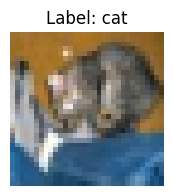

=== [1] First Conv Layer Filters ===


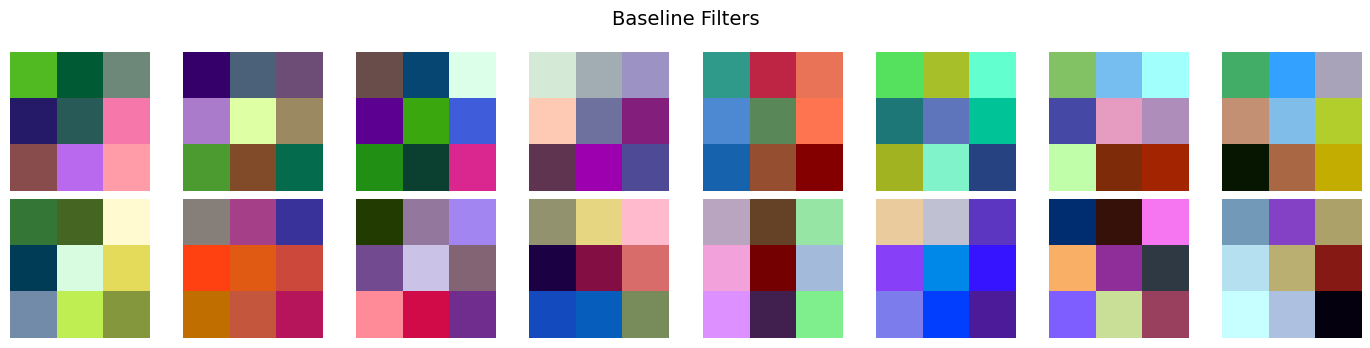

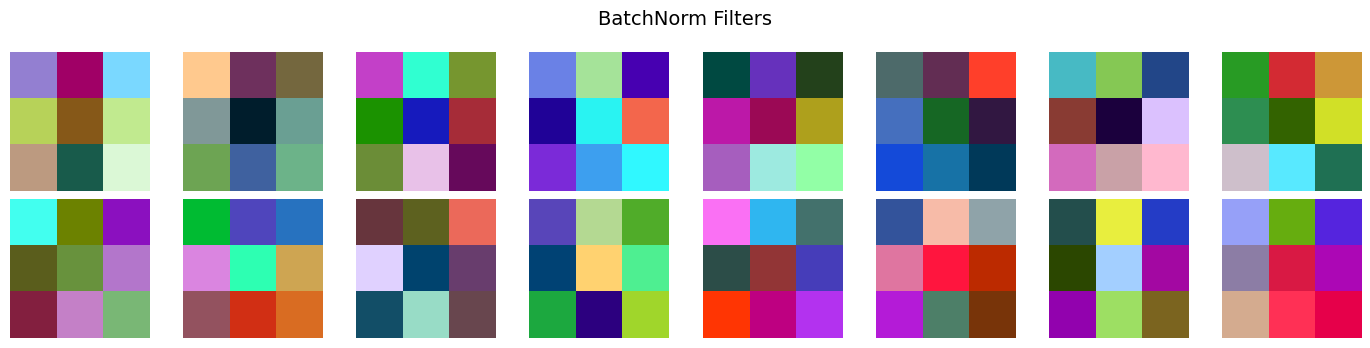


  [실험 1] 선택된 이미지 인덱스: 3


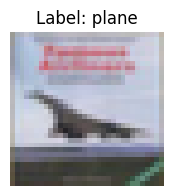


--- Feature Maps ---


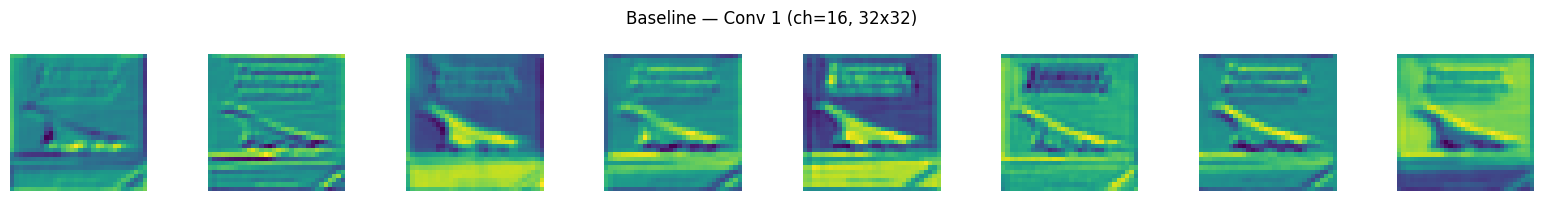

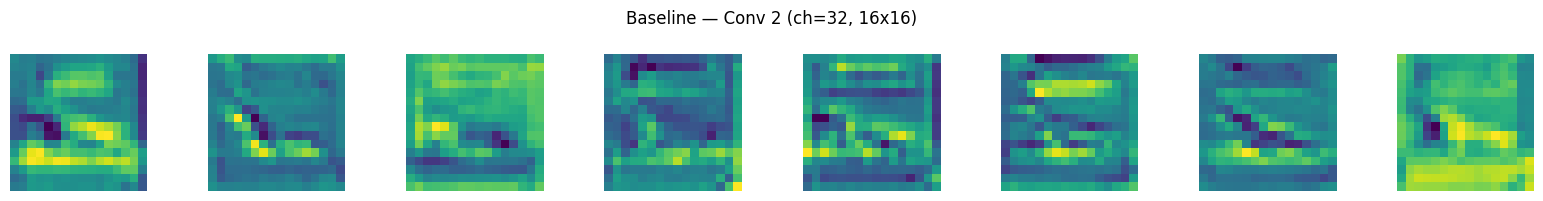

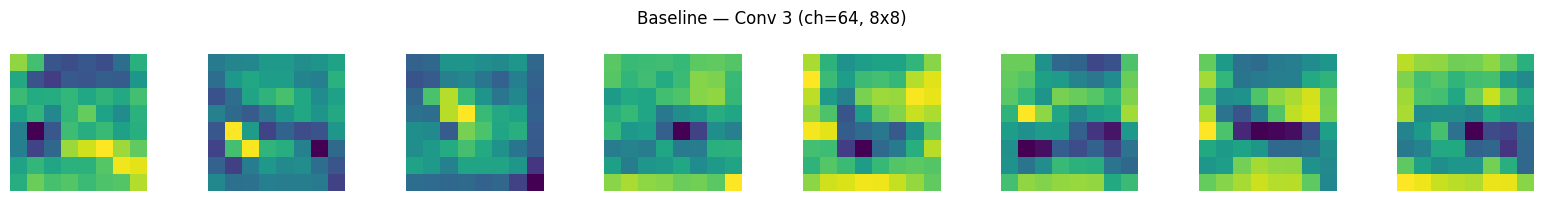

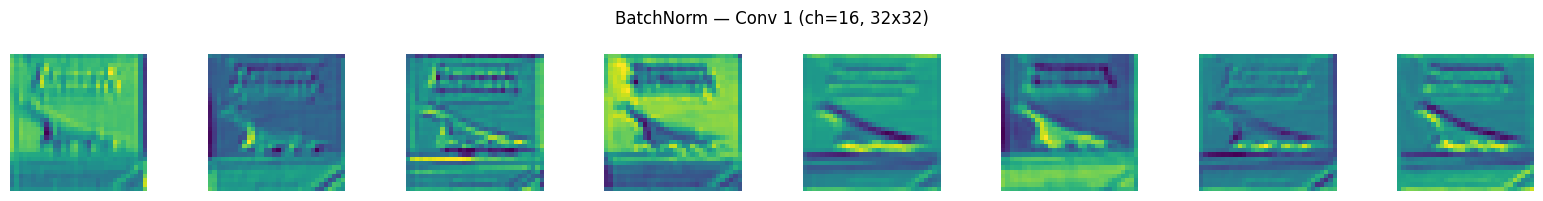

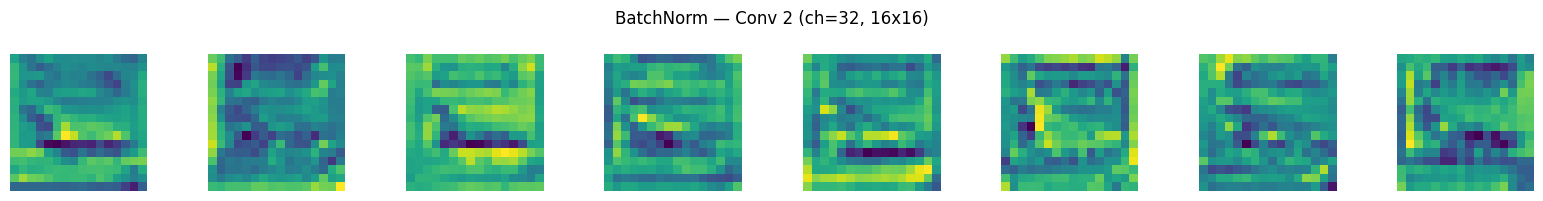

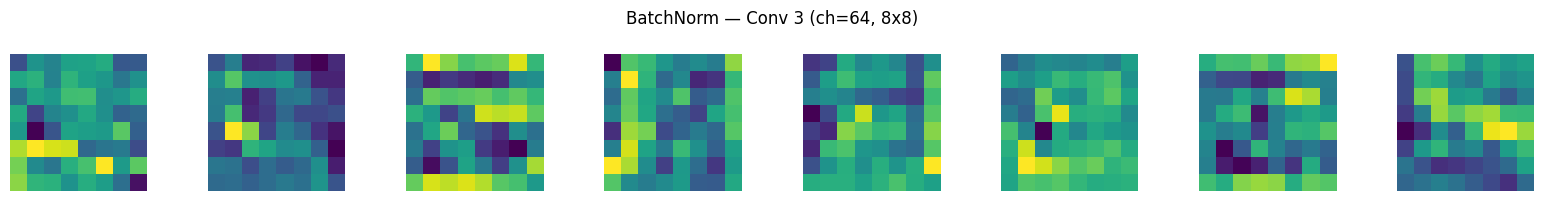


  [실험 2] 선택된 이미지 인덱스: 4


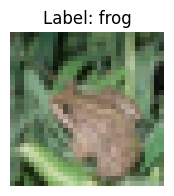


--- Feature Maps ---


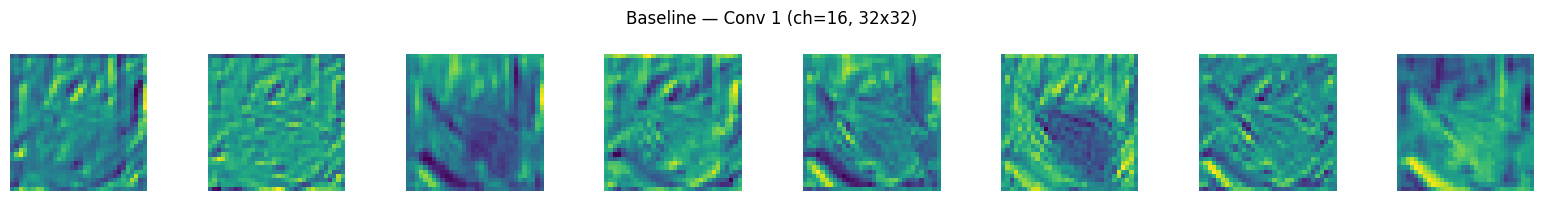

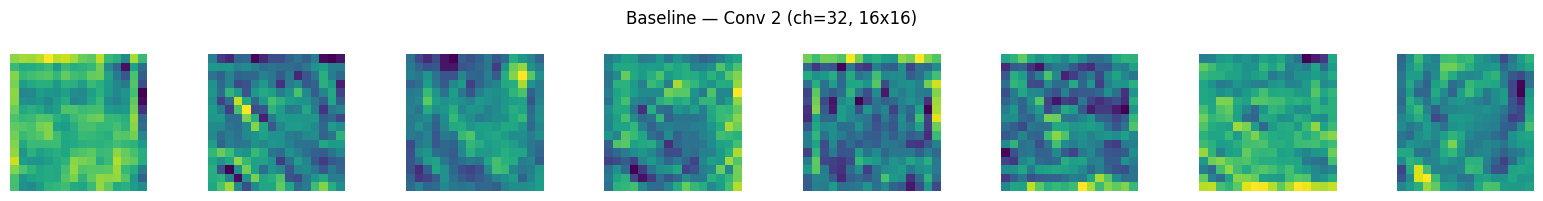

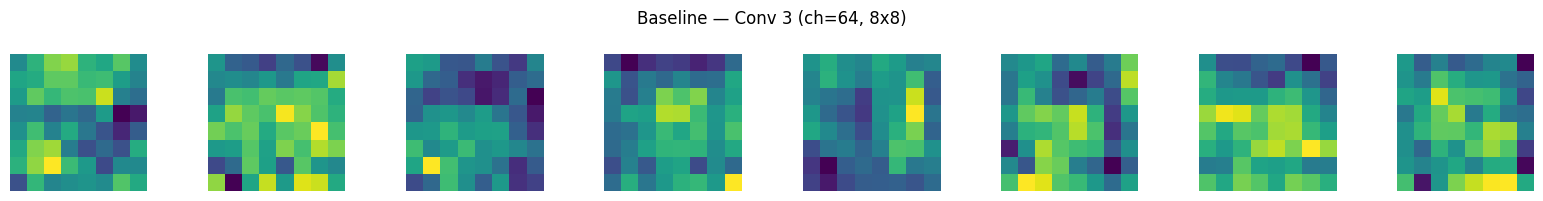

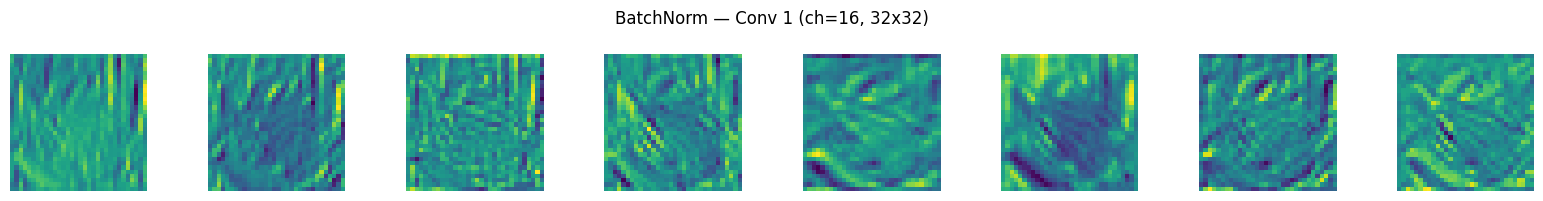

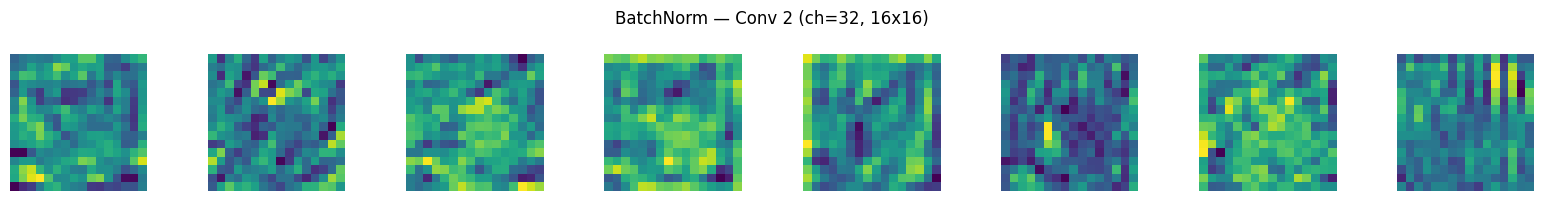

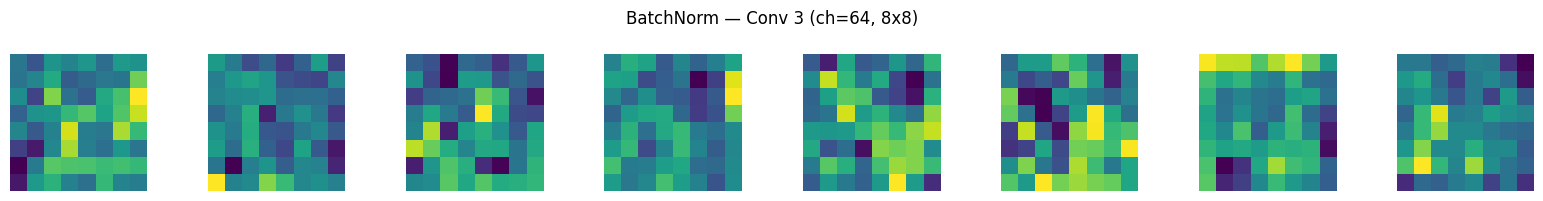


  [실험 3] 선택된 이미지 인덱스: 5


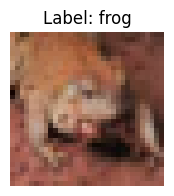


--- Feature Maps ---


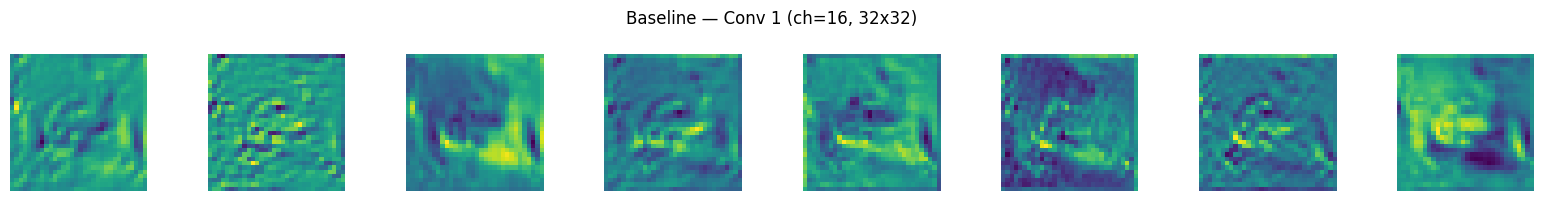

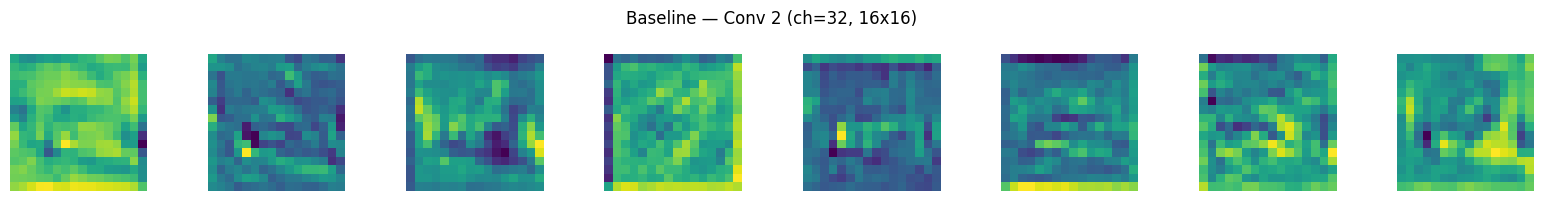

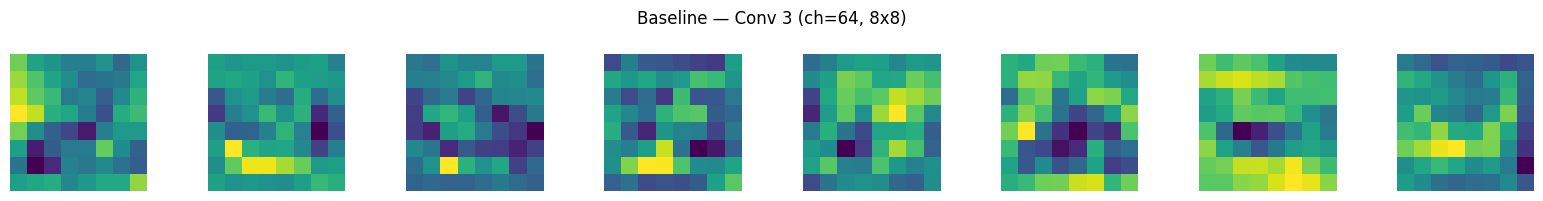

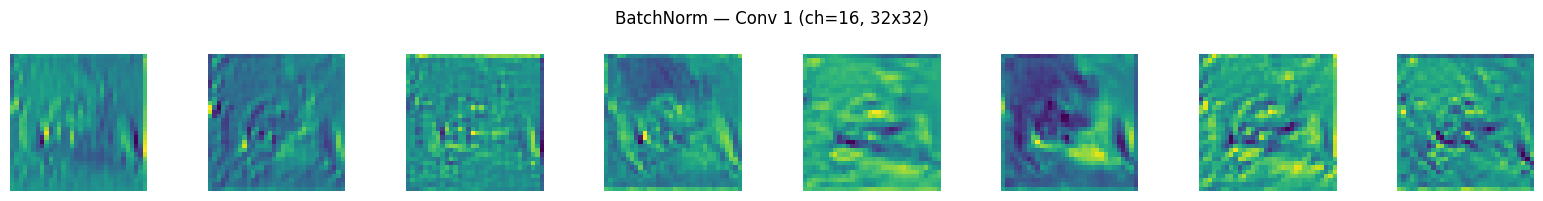

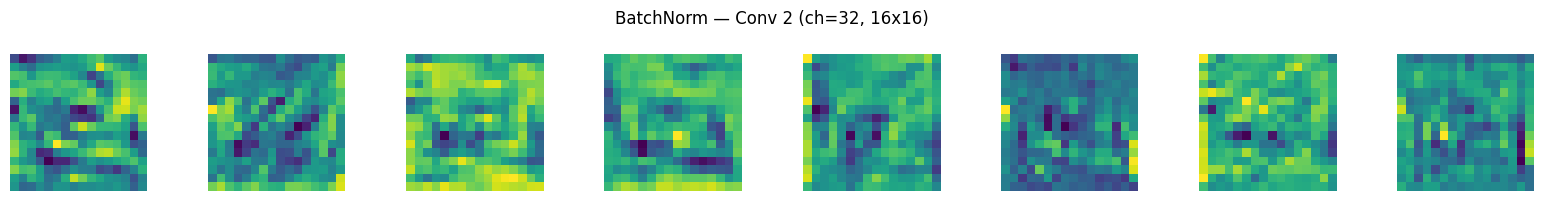

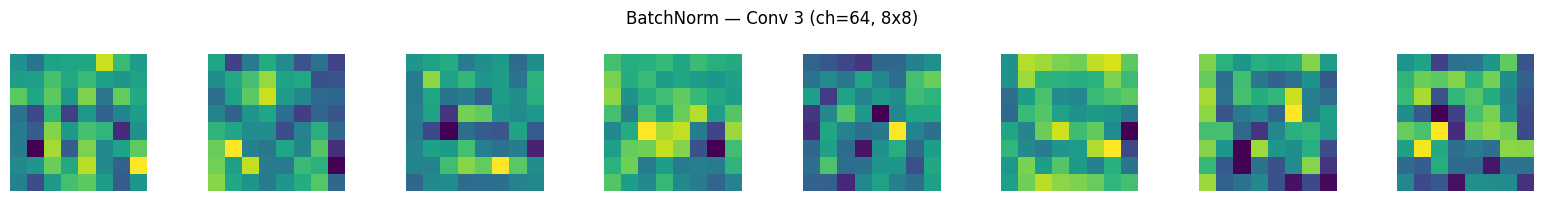


--- Grad-CAM ---


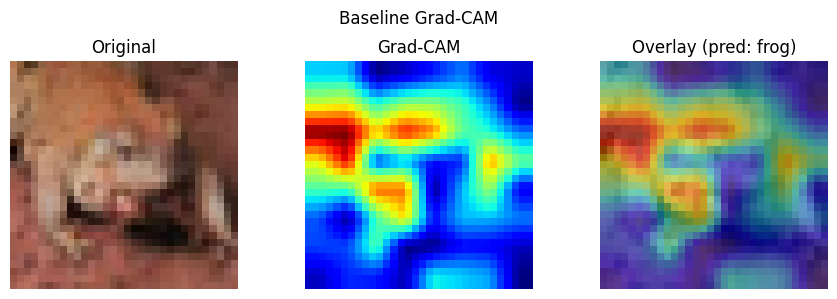

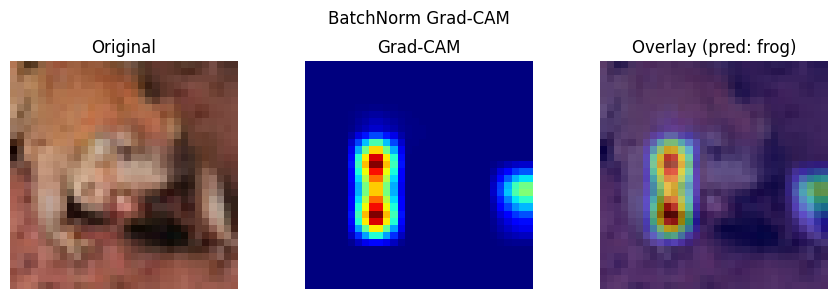

In [10]:
# --- Pick a sample image for visualization ---
sample_image, sample_label = testset[0]
show_original_image(sample_image, sample_label)

print("=== [1] First Conv Layer Filters ===")
visualize_filters(baseline, title="Baseline Filters")
visualize_filters(bn_model, title="BatchNorm Filters")


indices_to_try = [3, 4, 5]

for i, idx in enumerate(indices_to_try):
    sample_image, sample_label = testset[idx]

    print(f"\n==================================================")
    print(f"  [실험 {i+1}] 선택된 이미지 인덱스: {idx}")
    print(f"==================================================")


    show_original_image(sample_image, sample_label)


    print(f"\n--- Feature Maps ---")
    visualize_feature_maps(baseline, sample_image, title="Baseline")
    visualize_feature_maps(bn_model, sample_image, title="BatchNorm")


print(f"\n--- Grad-CAM ---")
show_grad_cam(baseline, sample_image, title="Baseline Grad-CAM")
show_grad_cam(bn_model, sample_image, title="BatchNorm Grad-CAM")


# TODO: Try at least 3 different images from different classes and compare.
#       Do the models focus on different regions?

### 5-1. Observation Questions

1. Describe the patterns you see in the first-layer filters. Do they resemble edge detectors, color detectors, or something else?
2. How do feature maps change from the first conv layer to the last? What does this suggest about hierarchical feature learning?
3. Compare the Grad-CAM heatmaps of the Baseline and BatchNorm models. Does one focus on more relevant image regions?
4. Did you find any images where one model's attention (Grad-CAM) was clearly better than the other's? Describe what you found.

1. 첫 번째 레이어 필터는 주로 Edge와 Color 대비를 감지한다. BatchNorm 모델의 필터가 Baseline 모델보다 노이즈가 적고 패턴이 훨씬 선명하게 나타난다.

2. 초기 레이어는 물체의 원래 형태를 유지하지만, 깊어질수록 사람이 알아보기 힘든 형태로 변한다. 이는 CNN이 단순한 Edge와 Color에서 복잡하고 의미 있는 특징으로 Hierarchical learning을 진행한 것이다.

3. BatchNorm 모델이 정답과 관련된 핵심 객체에 훨씬 잘 집중한다. Baseline은 배경이나 노이즈에 붉은색 히트맵이 넓고 산만하게 퍼지는 반면, BatchNorm은 물체 자체의 특징에 좁고 강하게 포커스를 맞춘다.

4. 개구리 이미지에서 차이가 명확했습니다. Baseline은 개구리뿐만 아니라 배경까지 넓게 과적합된 모습을 보이지만 BatchNorm은 배경을 무시하고 개구리의 발 부분에만 포커스 됐다.

---
## Task 6: Analysis

### 6-1. Compare Results

Final Test Set Evaluation:
  Baseline       : 0.7068
  Dropout        : 0.7420
  BatchNorm      : 0.7245
  Best Model     : 0.8557


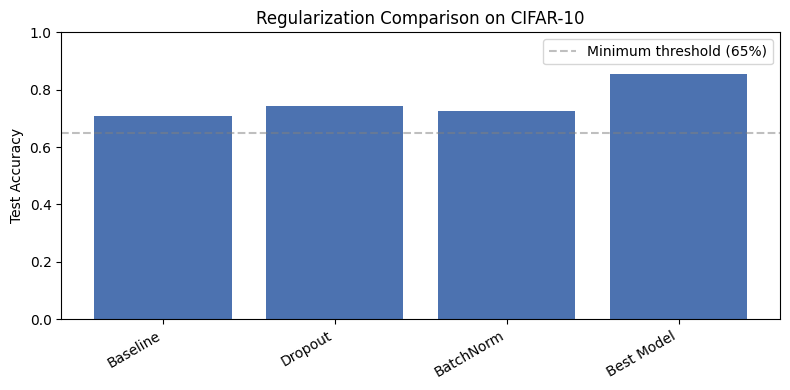

           AUTO-GRADE REPORT
  Baseline            : 70.7%  (>= 65%)  [PASS]
  Dropout             : 74.2%  (>= 65%)  [PASS]
  BatchNorm           : 72.5%  (>= 70%)  [PASS]
  Best Model          : 85.6%  (>= 70%)  [PASS]
---------------------------------------------
  Best Model Accuracy : 85.6%
  Grade               : A+


In [15]:
# Final evaluation on the TEST set (only done here, after all tuning is complete)
print('Final Test Set Evaluation:')
print('=' * 40)
results = {}
for name, model in [('Baseline', baseline), ('Dropout', dropout_model),
                     ('BatchNorm', bn_model), ('Best Model', best_model)]:
    _, acc = evaluate(model, testloader)
    results[name] = acc
    print(f'  {name:15s}: {acc:.4f}')
print('=' * 40)

# --- Bar Chart ---
plt.figure(figsize=(8, 4))
colors = ['#4C72B0' if v >= 0.65 else '#C44E52' for v in results.values()]
plt.bar(results.keys(), results.values(), color=colors)
plt.ylabel('Test Accuracy')
plt.title('Regularization Comparison on CIFAR-10')
plt.ylim(0, 1)
plt.axhline(y=0.65, color='gray', linestyle='--', alpha=0.5, label='Minimum threshold (65%)')
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# --- Auto-Grading ---
def compute_grade(best_acc):
    if best_acc >= 0.85: return 'A+'
    elif best_acc >= 0.82: return 'A'
    elif best_acc >= 0.79: return 'B+'
    elif best_acc >= 0.76: return 'B'
    elif best_acc >= 0.70: return 'C'
    else: return 'F'

thresholds = {
    'Baseline': 0.65,
    'Dropout': 0.65,
    'BatchNorm': 0.70,
    'Best Model': 0.70,
}

print('=' * 45)
print('           AUTO-GRADE REPORT')
print('=' * 45)
all_pass = True
for task, threshold in thresholds.items():
    acc = results[task]
    passed = acc >= threshold
    status = 'PASS' if passed else 'FAIL'
    if not passed:
        all_pass = False
    print(f'  {task:20s}: {acc:.1%}  (>= {threshold:.0%})  [{status}]')

best = results['Best Model']
grade = compute_grade(best)
print('-' * 45)
print(f'  Best Model Accuracy : {best:.1%}')
print(f'  Grade               : {grade}')
if not all_pass:
    print('  WARNING: Some tasks below minimum threshold!')
print('=' * 45)

### 6-2. Training Curves

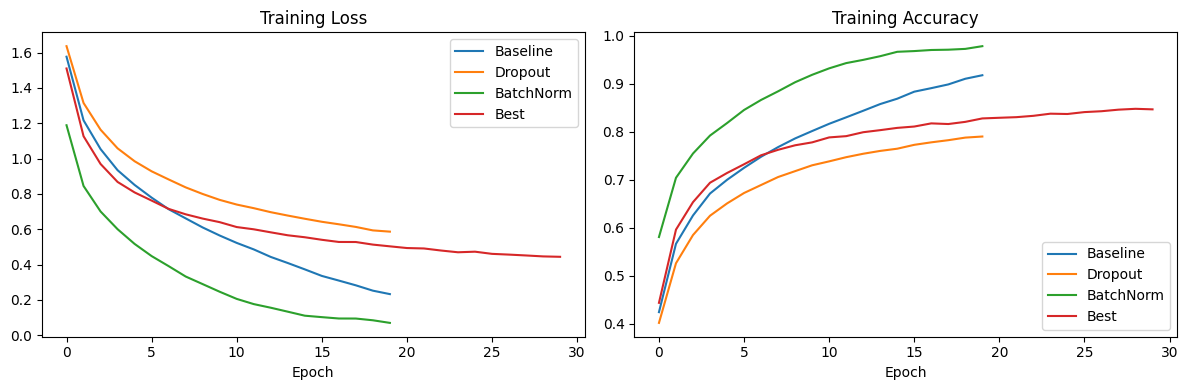

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for name, hist in [('Baseline', hist_baseline), ('Dropout', hist_dropout),
                    ('BatchNorm', hist_bn), ('Best', hist_best)]:
    ax1.plot(hist['loss'], label=name)
    ax2.plot(hist['acc'], label=name)

ax1.set_title('Training Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.set_title('Training Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout()
plt.show()

### 6-3. Questions (Answer in text cells below)

1. Which regularization technique (Dropout vs BatchNorm) gave the bigger improvement over the baseline? Why do you think so?
2. Compare the training curves (loss & accuracy) of the baseline vs. your best model. What differences do you observe regarding overfitting?
3. Based on your Grad-CAM visualizations from Task 5, which model (Baseline vs BatchNorm) focuses on more task-relevant image regions? How might this relate to their accuracy difference?

1. Dropout이 더 큰 Test Accuracy 향상을 가져왔다.
그 이유는 우리가 사용한 모델이 층이 얕은 '작은 신경망'이었기 때문입니다. BatchNorm은 데이터의 스케일을 맞춰주어 학습 속도(Optimization)를 미친 듯이 끌어올렸지만, 그 단점으로 Overfitting을 유발했습니다. 반면, Dropout은 과적합을 잡았기 때문에 실전 Test set에서 더 높은 일반화가 가능했다고 보인다.

2. Baseline은 에포크가 지날수록 Train Loss는 계속해서 하락하고 Train Accuracy는 90%를 넘지만 Test Accuracy는 72%에 머물러 있어, 훈련 데이터만 외운 Overfitting 곡선을 그린다.반면 Best Model은 Train Accuracy가 상대적으로 완만하게 오르며 최종 값도 85% 부근을 넘어가지 않는다. Test Accuracy는 86%로 Train Accuracy가 더 높게 나타나서 이미지의 feature를 잘 학습해서 Overfitting을 잘 잡은 것 같다


3. Grad-CAM 시각화 결과, BatchNorm 모델이 Baseline 모델보다 훨씬 더 Task-relevant regions에 포커스를 둔다.
Baseline 모델은 특정 객체를 예측할 때 히트맵이 산만하게 나타났습니다. 개구리 이미지를 예를 들자면, 개구리 자체뿐만 아니라 주변까지 붉은색 히트맵이 넓게 퍼져 있다. BatchNorm 모델은 예측해야 할 개구리 부분에만 강하게 포커스를 맞췄다. 이렇게 배경이 아닌 객체 자체의 Feature을 날카롭게 추출하기에 Accuracy 상승이 됐다고 볼 수 있다